In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)
type(mnist)

sklearn.utils._bunch.Bunch

In [2]:
X,y = mnist.data, mnist.target

In [5]:
mnist.DESCR

"**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 

In [3]:
X.shape

(70000, 784)

In [7]:
y.shape

(70000,)

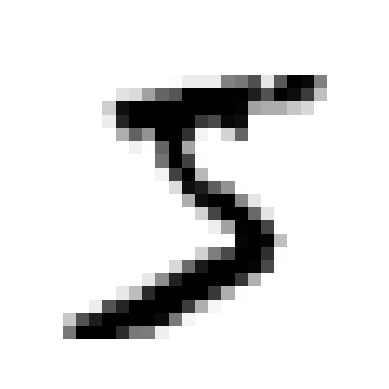

In [6]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image=image_data.reshape(28,28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)
plt.show()

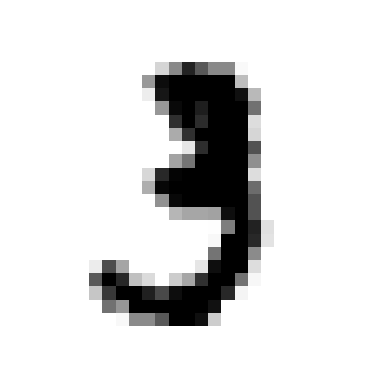

In [8]:
plot_digit(X[10])

In [9]:
y[10]

'3'

In [10]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

**Binary Classifier**

In [12]:
type(y_train_5)

numpy.ndarray

In [13]:
y_train_5 = (y_train=='5')
y_test_5 = (y_test=='5')

from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

In [14]:
sgd_clf.predict([some_digit])

array([ True])

In [15]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train,y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [17]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train,y_train_5)

DummyClassifier()

In [18]:
cross_val_score(dummy_clf, X_train,y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

In [19]:
from sklearn.model_selection import StratifiedKFold

In [20]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train,y_train_5,cv=3)

In [21]:
y_train_pred.shape


(60000,)

In [22]:
from sklearn.metrics import confusion_matrix

In [23]:
cm = confusion_matrix(y_train_5, y_train_pred)

In [24]:
cm

array([[53892,   687],
       [ 1891,  3530]])

In [25]:
confusion_matrix(y_train_5, y_train_5)

array([[54579,     0],
       [    0,  5421]])

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(precision_score(y_train_5, y_train_pred))
print(recall_score(y_train_5, y_train_pred))
print(f1_score(y_train_5, y_train_pred))

0.8370879772350012
0.6511713705958311
0.7325171197343847


In [31]:
y_scores=sgd_clf.decision_function([some_digit])

In [41]:
y_scores=sgd_clf.decision_function(X_train)

In [42]:
y_scores

array([  2164.22030239,  -5897.37359354, -13489.14805779, ...,
         6007.43513003,   -695.89564908,  -3991.49590678])

In [34]:
thr=0
y_some_digit_pred = y_scores  > thr

y_some_digit_pred

array([ True])

In [33]:
thr=3000
y_some_digit_pred = y_scores  > thr
y_some_digit_pred

array([False])

In [43]:
from sklearn.metrics import precision_recall_curve
precision, recall, thr = precision_recall_curve(y_train_5, y_scores)

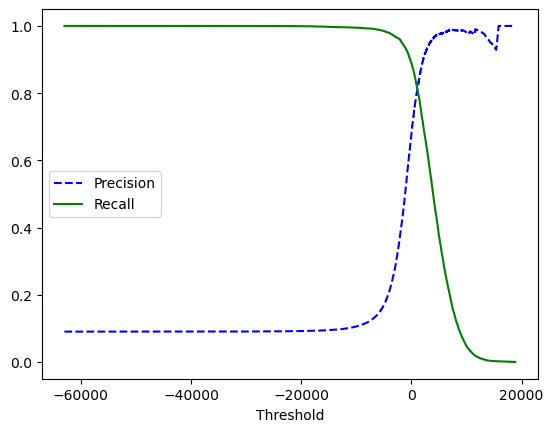

In [48]:
plt.plot(thr, precision[:-1],'b--', label='Precision')
plt.plot(thr, recall[:-1],'g-', label='Recall')
plt.xlabel('Threshold')
plt.legend()

In [49]:
precision[-1]

np.float64(1.0)

In [50]:
idx_for_90_precision = (precision>=0.9).argmax()
thr_for_90_precision = thr[idx_for_90_precision]
thr_for_90_precision

np.float64(2123.562046995017)

In [51]:
recall[idx_for_90_precision]

np.float64(0.7061427780852241)